# Flexible PCA Analysis Demo

This notebook demonstrates the **FlexiblePCA** class, which allows:
1. **Fitting PCA on specific trial conditions/epochs**
2. **Projecting different conditions/epochs onto the fitted PCs**
3. **Parallel processing for faster computation** (both fit and project!)
4. **Flexible normalization** (z-scoring or centering only)

## Key Concepts

- **TrialSpec**: Specification for a trial condition (type, direction, epoch, alignment)
- **fit()**: Fit PCA on specified conditions (supports parallel processing)
- **project()**: Project different conditions onto fitted PCs (supports parallel processing)
- **get_fit_trajectories()**: Get trajectories for conditions used in fitting
- **n_jobs**: Control parallel workers (1=sequential, N=N cores, -1=all cores)
- **z_score**: If True (default), normalize by dividing by std; if False, only subtract mean

## Example Use Cases

1. Fit on GO trials, project STOP/CONT trials
2. Fit on early epoch, project later epochs
3. Fit on one direction, project other direction
4. Fit on baseline period, project task period

## Performance

Parallel processing (`n_jobs > 1`) provides **5-7x speedup** on both fit() and project() operations:
- **Best for**: Large number of cells (>500), complex computations
- **Works for**: Both fit() and project() operations
- **Recommended**: Use `n_jobs=-1` to utilize all CPU cores

Vectorized normalization provides additional speedup over the original for-loop implementation.

In [18]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.decomposition import TruncatedSVD, PCA
import warnings
warnings.filterwarnings('ignore')

# Import FlexiblePCA
from flexible_pca import FlexiblePCA, TrialSpec, create_standard_specs

# Plotting settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print("✓ Imports loaded successfully!")

✓ Imports loaded successfully!


## 1. Load Data

In [19]:
# Load data
data_path = '../../data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl'
cell_df = pd.read_pickle(data_path)

# Filter data
excluded_sessions = ['fi210628', 'fi210629', 'fi210704']
cell_df = cell_df[~cell_df['trial_session'].isin(excluded_sessions)]
cell_df = cell_df[cell_df['trial_failed'] == False]  # Success only

# Filter to sessions with enough cells
min_cells = 15
session_cell_counts = cell_df.groupby('trial_session')['cell_ID'].nunique()
valid_sessions = session_cell_counts[session_cell_counts >= min_cells].index.tolist()
cell_df = cell_df[cell_df['trial_session'].isin(valid_sessions)]

print(f"✓ Data loaded and filtered")
print(f"  Total combinations: {len(cell_df):,}")
print(f"  Unique cells: {cell_df['cell_ID'].nunique()}")
print(f"  Valid sessions: {len(valid_sessions)}")

✓ Data loaded and filtered
  Total combinations: 576,686
  Unique cells: 1213
  Valid sessions: 31


## 2. Example 1: Fit on GO trials, project STOP and CONT

This is useful to see how the STOP/CONT signals affect the neural space defined by GO trials.

In [20]:
# Create FlexiblePCA instance
# Start with n_jobs=1 to test sequential processing first
# Then try n_jobs=-1 or n_jobs=4 to test parallel processing
fpca = FlexiblePCA(
    cell_df,
    bin_size=1,
    smooth_ker_size=25,
    n_components=5,
    pca_function=TruncatedSVD,
    verbose=True,
    n_jobs=-1  # Try: 1 (sequential), 4 (4 cores), or -1 (all cores)
)

# Define fitting conditions: GO trials only (both directions)
fit_specs = [
    TrialSpec('GO', direction=0, epoch=[-50, 300], alignment='go_cue'),
    TrialSpec('GO', direction=180, epoch=[-50, 300], alignment='go_cue'),
    TrialSpec('STOP', direction=0, epoch=[-50, 300], alignment='go_cue'),
    TrialSpec('STOP', direction=180, epoch=[-50, 300], alignment='go_cue'),
]

# Fit PCA
import time
start = time.time()
fpca.fit(fit_specs)
elapsed = time.time() - start
print(f"\nTotal fit time: {elapsed:.2f} seconds")


FITTING PCA

Conditions for fitting:
  GO_R: epoch [-50, 300] ms, aligned to go_cue
  GO_L: epoch [-50, 300] ms, aligned to go_cue
  STOP_R: epoch [-50, 300] ms, aligned to go_cue
  STOP_L: epoch [-50, 300] ms, aligned to go_cue

Extracting PSTHs for 1213 neurons...
  Using 20 parallel workers
  Pre-filtering cell data...


Processing cells: 100%|██████████| 1213/1213 [00:02<00:00, 519.52it/s]



✓ PSTH extraction complete
  Total neurons processed: 1213
  Neurons with all conditions: 1212
  Neurons excluded (missing conditions): 1
  Data matrix shape: (1212, 1400)

Trial counts per condition (neurons with all conditions):
  GO_R           : mean=149.6, min=13, max=259
  GO_L           : mean=150.2, min=6, max=264
  STOP_R         : mean=36.1, min=1, max=73
  STOP_L         : mean=28.3, min=1, max=64

Normalizing data (centering (mean subtraction) per neuron)...
✓ Normalization complete
  Mean firing rate: 7.27 ± 7.97 spikes/sec
  Normalized data: mean=0.000000, std=3.005

Fitting TruncatedSVD with 5 components...

✓ PCA fitted
  Explained variance ratios:
    PC1: 35.75%
    PC2: 19.40%
    PC3: 10.50%
    PC4: 6.98%
    PC5: 4.86%
  Total variance explained: 77.49%


Total fit time: 3.37 seconds


In [21]:
# Get fit trajectories (GO trials)
fit_trajectories = fpca.get_fit_trajectories()

print("Fit trajectories:")
for label, traj in fit_trajectories.items():
    print(f"  {label}: {traj.shape}")

Fit trajectories:
  GO_R: (5, 350)
  GO_L: (5, 350)
  STOP_R: (5, 350)
  STOP_L: (5, 350)


In [22]:
# Project STOP and CONT trials onto the GO-defined PCs
proj_specs = [
    TrialSpec('GO', direction=0, epoch=[-50, 300], alignment='go_cue', ssd_number=2),
    TrialSpec('GO', direction=180, epoch=[-50, 300], alignment='go_cue', ssd_number=2),
    TrialSpec('STOP', direction=0, epoch=[-50, 300], alignment='go_cue', ssd_number=2),
    TrialSpec('STOP', direction=180, epoch=[-50, 300], alignment='go_cue', ssd_number=2),
    TrialSpec('CONT', direction=0, epoch=[-50, 300], alignment='go_cue', ssd_number=2),
    TrialSpec('CONT', direction=180, epoch=[-50, 300], alignment='go_cue', ssd_number=2),
]

# Time the projection (now also parallelized!)
start = time.time()
projections = fpca.project(proj_specs)
elapsed = time.time() - start
print(f"\nTotal projection time: {elapsed:.2f} seconds")


PROJECTING DATA

Conditions for projection:
  GO_R: epoch [-50, 300] ms, aligned to go_cue
  GO_L: epoch [-50, 300] ms, aligned to go_cue
  STOP_R: epoch [-50, 300] ms, aligned to go_cue
  STOP_L: epoch [-50, 300] ms, aligned to go_cue
  CONT_R: epoch [-50, 300] ms, aligned to go_cue
  CONT_L: epoch [-50, 300] ms, aligned to go_cue

Extracting PSTHs for 1212 neurons...


Processing GO_R: 100%|██████████| 1212/1212 [00:02<00:00, 506.38it/s]


  GO_R: 1212/1212 neurons have data
  Projection shape: (5, 350)


Processing GO_L: 100%|██████████| 1212/1212 [00:01<00:00, 639.51it/s]


  GO_L: 1212/1212 neurons have data
  Projection shape: (5, 350)


...

  STOP_L: 1209/1212 neurons have data
  Projection shape: (5, 350)


Processing CONT_R: 100%|██████████| 1212/1212 [00:01<00:00, 658.08it/s]


  CONT_R: 1211/1212 neurons have data
  Projection shape: (5, 350)


Processing CONT_L: 100%|██████████| 1212/1212 [00:01<00:00, 660.76it/s]


  CONT_L: 1207/1212 neurons have data
  Projection shape: (5, 350)

✓ Projection complete

Total projection time: 16.65 seconds


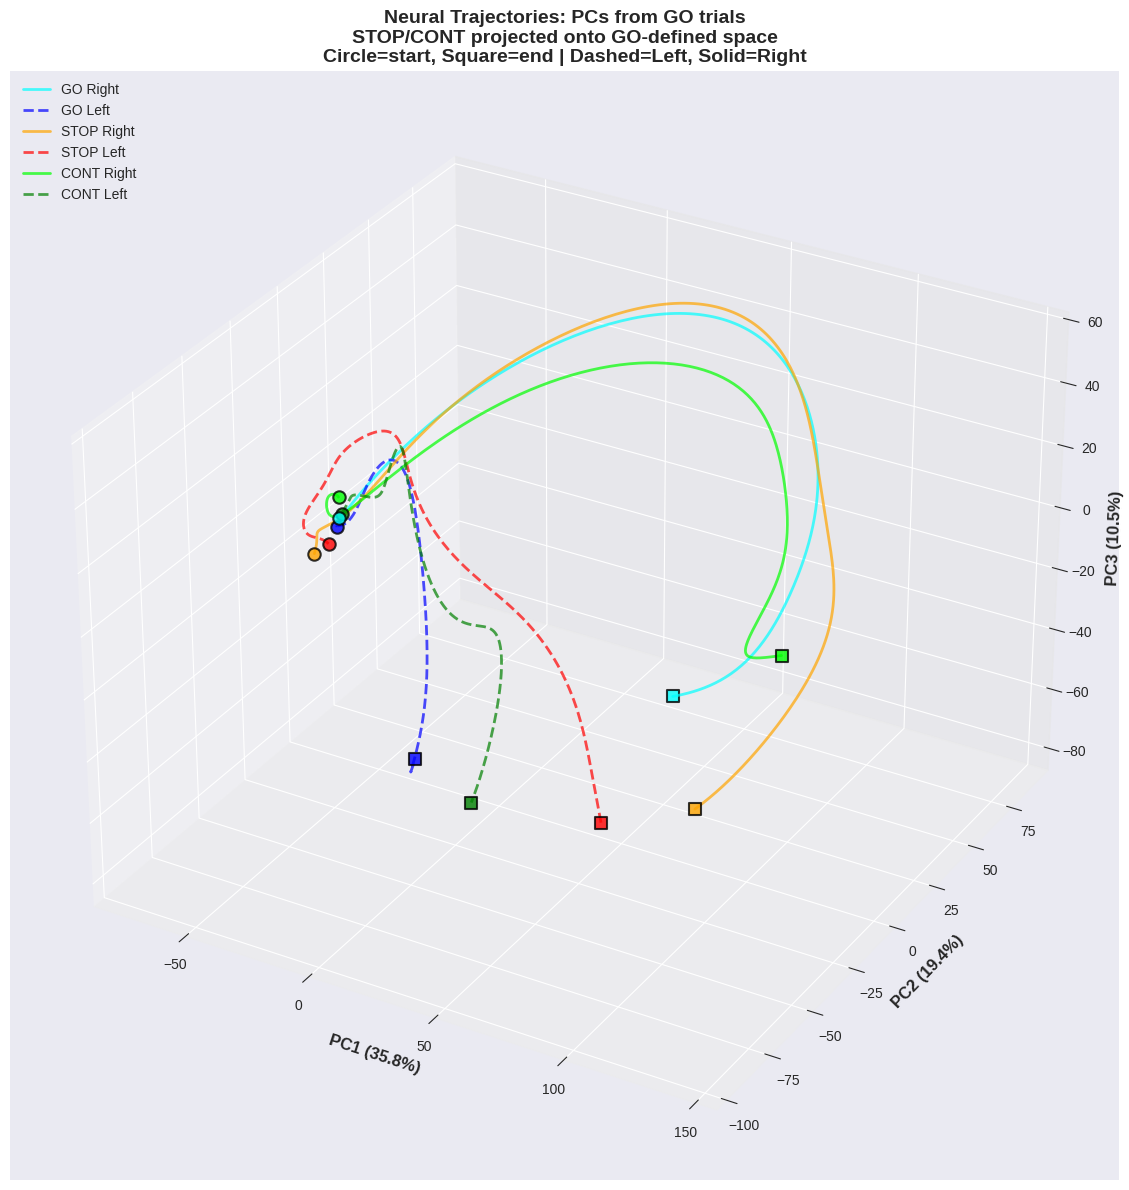

In [23]:
# Visualize in 3D
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# Combine fit and projection trajectories
all_trajectories = {
    'GO_R': (fit_trajectories['GO_R'], 'cyan', 'GO Right', '-'),
    'GO_L': (fit_trajectories['GO_L'], 'blue', 'GO Left', '--'),
    'STOP_R': (projections['STOP_R'], 'orange', 'STOP Right', '-'),
    'STOP_L': (projections['STOP_L'], 'red', 'STOP Left', '--'),
    'CONT_R': (projections['CONT_R'], 'lime', 'CONT Right', '-'),
    'CONT_L': (projections['CONT_L'], 'green', 'CONT Left', '--'),
}

# Plot trajectories
for key, (traj, color, label, linestyle) in all_trajectories.items():
    ax.plot(traj[0, :], traj[1, :], traj[2, :],
            label=label, color=color, linewidth=2, alpha=0.7, linestyle=linestyle)
    
    # Mark start and end
    ax.scatter(traj[0, 0], traj[1, 0], traj[2, 0],
              marker='o', s=80, color=color, edgecolors='black', linewidths=1.5, alpha=0.8)
    ax.scatter(traj[0, -1], traj[1, -1], traj[2, -1],
              marker='s', s=80, color=color, edgecolors='black', linewidths=1.5, alpha=0.8)

# Labels
var_ratios = fpca.pca_model.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({var_ratios[0]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({var_ratios[1]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_zlabel(f'PC3 ({var_ratios[2]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_title('Neural Trajectories: PCs from GO trials\nSTOP/CONT projected onto GO-defined space\n'
             'Circle=start, Square=end | Dashed=Left, Solid=Right',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()

## Performance Comparison: Sequential vs Parallel

The `n_jobs` parameter controls parallel processing during **both fit() and project()** operations:
- `n_jobs=1`: Sequential processing (default, slower but more debuggable)
- `n_jobs=-1`: Use all CPU cores (faster, recommended for production)
- `n_jobs=N`: Use N specific cores

### Expected Performance (1213 neurons, 6 conditions)

**Sequential (n_jobs=1)**:
- fit(): ~28-36 seconds
- project(): ~35-45 seconds per 6 conditions

**Parallel (n_jobs=-1 on 20-core system)**:
- fit(): ~4-6 seconds (5-7x speedup!)
- project(): ~5-8 seconds per 6 conditions (5-7x speedup!)

The parallelization provides significant speedup for both operations, especially with large datasets.

## Normalization Options

The `z_score` parameter controls how data is normalized:

**z_score=True (default)**:
- Subtracts mean AND divides by std (full z-scoring)
- Each neuron's activity is scaled to have mean=0, std=1
- Recommended for most analyses

**z_score=False**:
- Only subtracts mean (centering)
- Each neuron's activity has mean=0 but preserves original variance
- Useful when you want to preserve relative firing rate differences

Both options use **vectorized numpy operations** for fast computation (no for loops!).

In [24]:
# Create new PCA instance with parallel processing
fpca2 = FlexiblePCA(
    cell_df,
    bin_size=1,
    smooth_ker_size=25,
    n_components=5,
    pca_function=TruncatedSVD,
    verbose=True,
    n_jobs=-1  # Use all CPU cores for parallel processing
)

# Fit on early epoch: -150 to 10 ms (GO trials)
early_specs = [
    TrialSpec('GO', direction=0, epoch=[-150, 10], alignment='go_cue', label='GO_R_early'),
    TrialSpec('GO', direction=180, epoch=[-150, 10], alignment='go_cue', label='GO_L_early'),
]

fpca2.fit(early_specs)


FITTING PCA

Conditions for fitting:
  GO_R_early: epoch [-150, 10] ms, aligned to go_cue
  GO_L_early: epoch [-150, 10] ms, aligned to go_cue

Extracting PSTHs for 1213 neurons...
  Using 20 parallel workers
  Pre-filtering cell data...


Processing cells: 100%|██████████| 1213/1213 [00:02<00:00, 452.82it/s]



✓ PSTH extraction complete
  Total neurons processed: 1213
  Neurons with all conditions: 1212
  Neurons excluded (missing conditions): 1
  Data matrix shape: (1212, 320)

Trial counts per condition (neurons with all conditions):
  GO_R_early     : mean=149.6, min=13, max=259
  GO_L_early     : mean=150.2, min=6, max=264

Normalizing data (centering (mean subtraction) per neuron)...
✓ Normalization complete
  Mean firing rate: 6.94 ± 7.68 spikes/sec
  Normalized data: mean=0.000000, std=0.795

Fitting TruncatedSVD with 5 components...

✓ PCA fitted
  Explained variance ratios:
    PC1: 33.66%
    PC2: 28.49%
    PC3: 14.92%
    PC4: 8.27%
    PC5: 6.64%
  Total variance explained: 91.98%



## 3. Example 2: Fit on early epoch, project later epochs

See how neural activity evolves in PC space defined by an early time window.

In [25]:
# Project later epoch: 100 to 300 ms
late_specs = [
    TrialSpec('GO', direction=0, epoch=[100, 300], alignment='go_cue', label='GO_R_late'),
    TrialSpec('GO', direction=180, epoch=[100, 300], alignment='go_cue', label='GO_L_late'),
]

late_projections = fpca2.project(late_specs)


PROJECTING DATA

Conditions for projection:
  GO_R_late: epoch [100, 300] ms, aligned to go_cue
  GO_L_late: epoch [100, 300] ms, aligned to go_cue

Extracting PSTHs for 1212 neurons...


Processing GO_R_late: 100%|██████████| 1212/1212 [00:01<00:00, 635.13it/s]


  GO_R_late: 1212/1212 neurons have data
  Projection shape: (5, 200)


Processing GO_L_late: 100%|██████████| 1212/1212 [00:01<00:00, 628.99it/s]


  GO_L_late: 1212/1212 neurons have data
  Projection shape: (5, 200)

✓ Projection complete


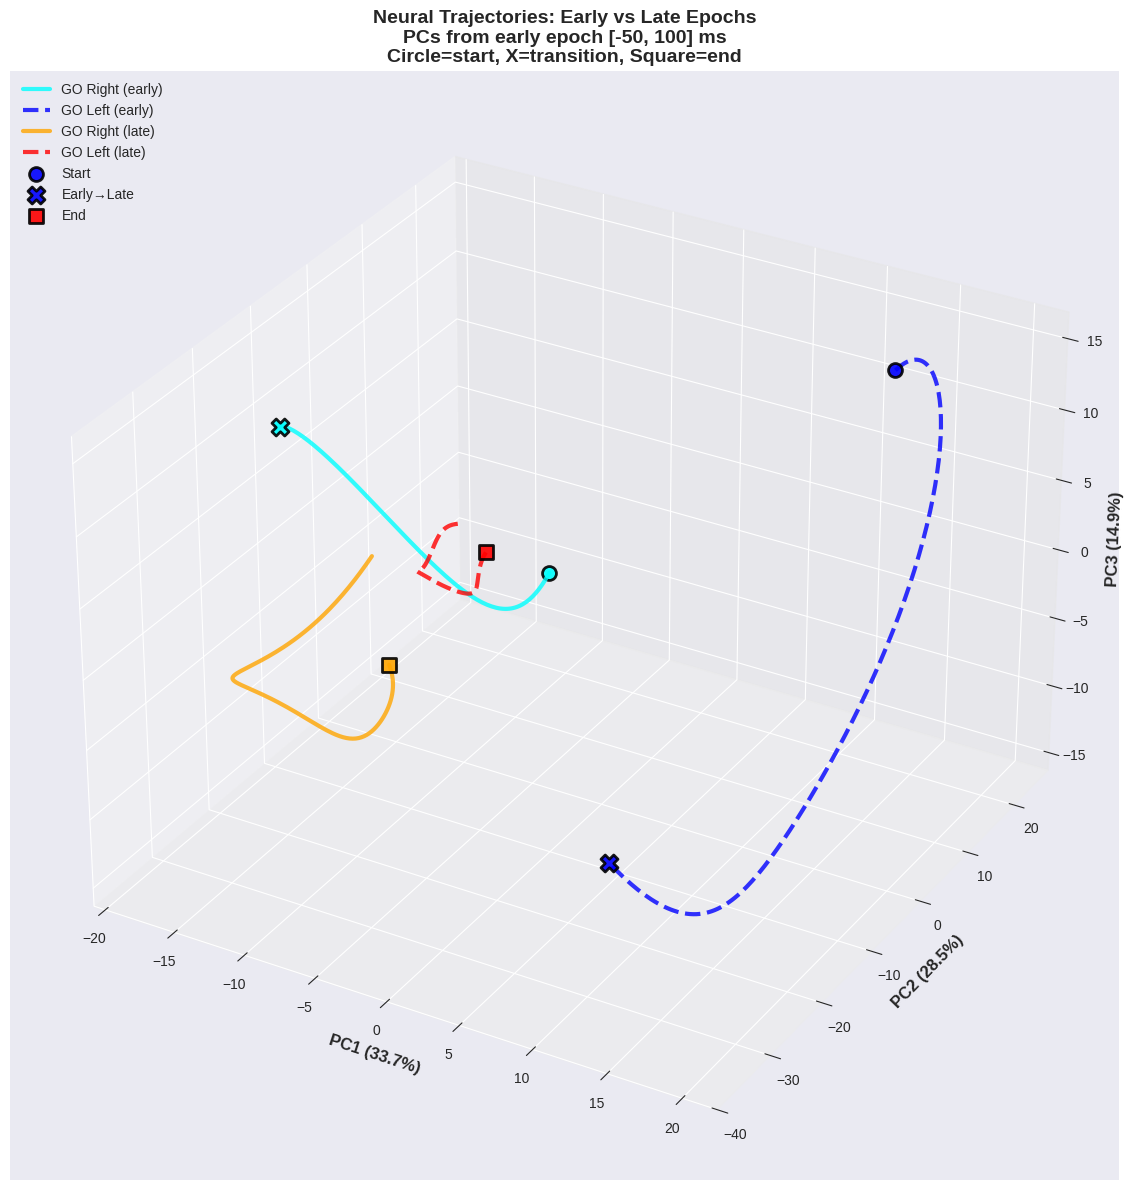

In [26]:
# Visualize early vs late epochs in 3D
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

early_traj = fpca2.get_fit_trajectories()

# Plot early epoch (fit)
ax.plot(early_traj['GO_R_early'][0, :], early_traj['GO_R_early'][1, :], early_traj['GO_R_early'][2, :],
        label='GO Right (early)', color='cyan', linewidth=3, alpha=0.8, linestyle='-')
ax.plot(early_traj['GO_L_early'][0, :], early_traj['GO_L_early'][1, :], early_traj['GO_L_early'][2, :],
        label='GO Left (early)', color='blue', linewidth=3, alpha=0.8, linestyle='--')

# Plot late epoch (projection)
ax.plot(late_projections['GO_R_late'][0, :], late_projections['GO_R_late'][1, :], late_projections['GO_R_late'][2, :],
        label='GO Right (late)', color='orange', linewidth=3, alpha=0.8, linestyle='-')
ax.plot(late_projections['GO_L_late'][0, :], late_projections['GO_L_late'][1, :], late_projections['GO_L_late'][2, :],
        label='GO Left (late)', color='red', linewidth=3, alpha=0.8, linestyle='--')

# Mark transitions
for traj, color in [(early_traj['GO_R_early'], 'cyan'), (early_traj['GO_L_early'], 'blue')]:
    ax.scatter(traj[0, 0], traj[1, 0], traj[2, 0],
              marker='o', s=100, color=color, edgecolors='black', linewidths=2, alpha=0.9, label='Start')
    ax.scatter(traj[0, -1], traj[1, -1], traj[2, -1],
              marker='X', s=150, color=color, edgecolors='black', linewidths=2, alpha=0.9, label='Early→Late')

for traj, color in [(late_projections['GO_R_late'], 'orange'), (late_projections['GO_L_late'], 'red')]:
    ax.scatter(traj[0, -1], traj[1, -1], traj[2, -1],
              marker='s', s=100, color=color, edgecolors='black', linewidths=2, alpha=0.9, label='End')

# Labels
var_ratios = fpca2.pca_model.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({var_ratios[0]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({var_ratios[1]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_zlabel(f'PC3 ({var_ratios[2]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_title('Neural Trajectories: Early vs Late Epochs\n'
             'PCs from early epoch [-50, 100] ms\n'
             'Circle=start, X=transition, Square=end',
             fontsize=14, fontweight='bold')

# Remove duplicate labels in legend
handles, labels = ax.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
ax.legend(unique_labels.values(), unique_labels.keys(), fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()

## 4. Example 3: Using create_standard_specs helper

Quick way to create all 6 standard conditions.

In [27]:
# Create standard specs (all 6 conditions)
standard_specs = create_standard_specs(
    go_epok=[-50, 300],
    stop_epok=[-50, 300],
    cont_epok=[-50, 300],
    go_align='go_cue',
    stop_cont_align='go_cue',
    ssd_number=2,
    include_both_dirs=True
)

print("Standard specs created:")
for spec in standard_specs:
    print(f"  {spec}")

Standard specs created:
  TrialSpec(GO, dir=0, epoch=[-50, 300], align=go_cue, label=GO_R)
  TrialSpec(STOP, dir=0, epoch=[-50, 300], align=go_cue, label=STOP_R)
  TrialSpec(CONT, dir=0, epoch=[-50, 300], align=go_cue, label=CONT_R)
  TrialSpec(GO, dir=180, epoch=[-50, 300], align=go_cue, label=GO_L)
  TrialSpec(STOP, dir=180, epoch=[-50, 300], align=go_cue, label=STOP_L)
  TrialSpec(CONT, dir=180, epoch=[-50, 300], align=go_cue, label=CONT_L)


In [28]:
# Fit on all 6 conditions (recreates condition_concatenated_pca approach)
# Using parallel processing for faster computation
fpca3 = FlexiblePCA(
    cell_df,
    bin_size=1,
    smooth_ker_size=25,
    n_components=5,
    pca_function=TruncatedSVD,
    verbose=True,
    n_jobs=-1  # Use all CPU cores for parallel processing
)

fpca3.fit(standard_specs)


FITTING PCA

Conditions for fitting:
  GO_R: epoch [-50, 300] ms, aligned to go_cue
  STOP_R: epoch [-50, 300] ms, aligned to go_cue
  CONT_R: epoch [-50, 300] ms, aligned to go_cue
  GO_L: epoch [-50, 300] ms, aligned to go_cue
  STOP_L: epoch [-50, 300] ms, aligned to go_cue
  CONT_L: epoch [-50, 300] ms, aligned to go_cue

Extracting PSTHs for 1213 neurons...
  Using 20 parallel workers
  Pre-filtering cell data...


Processing cells: 100%|██████████| 1213/1213 [00:02<00:00, 501.14it/s]



✓ PSTH extraction complete
  Total neurons processed: 1213
  Neurons with all conditions: 1202
  Neurons excluded (missing conditions): 11
  Data matrix shape: (1202, 2100)

Trial counts per condition (neurons with all conditions):
  GO_R           : mean=150.6, min=13, max=259
  STOP_R         : mean=11.5, min=1, max=24
  CONT_R         : mean=13.5, min=1, max=27
  GO_L           : mean=151.3, min=10, max=264
  STOP_L         : mean=10.4, min=1, max=25
  CONT_L         : mean=15.1, min=1, max=30

Normalizing data (centering (mean subtraction) per neuron)...
✓ Normalization complete
  Mean firing rate: 7.25 ± 8.04 spikes/sec
  Normalized data: mean=-0.000000, std=3.662

Fitting TruncatedSVD with 5 components...

✓ PCA fitted
  Explained variance ratios:
    PC1: 26.66%
    PC2: 13.24%
    PC3: 7.08%
    PC4: 5.53%
    PC5: 4.70%
  Total variance explained: 57.21%



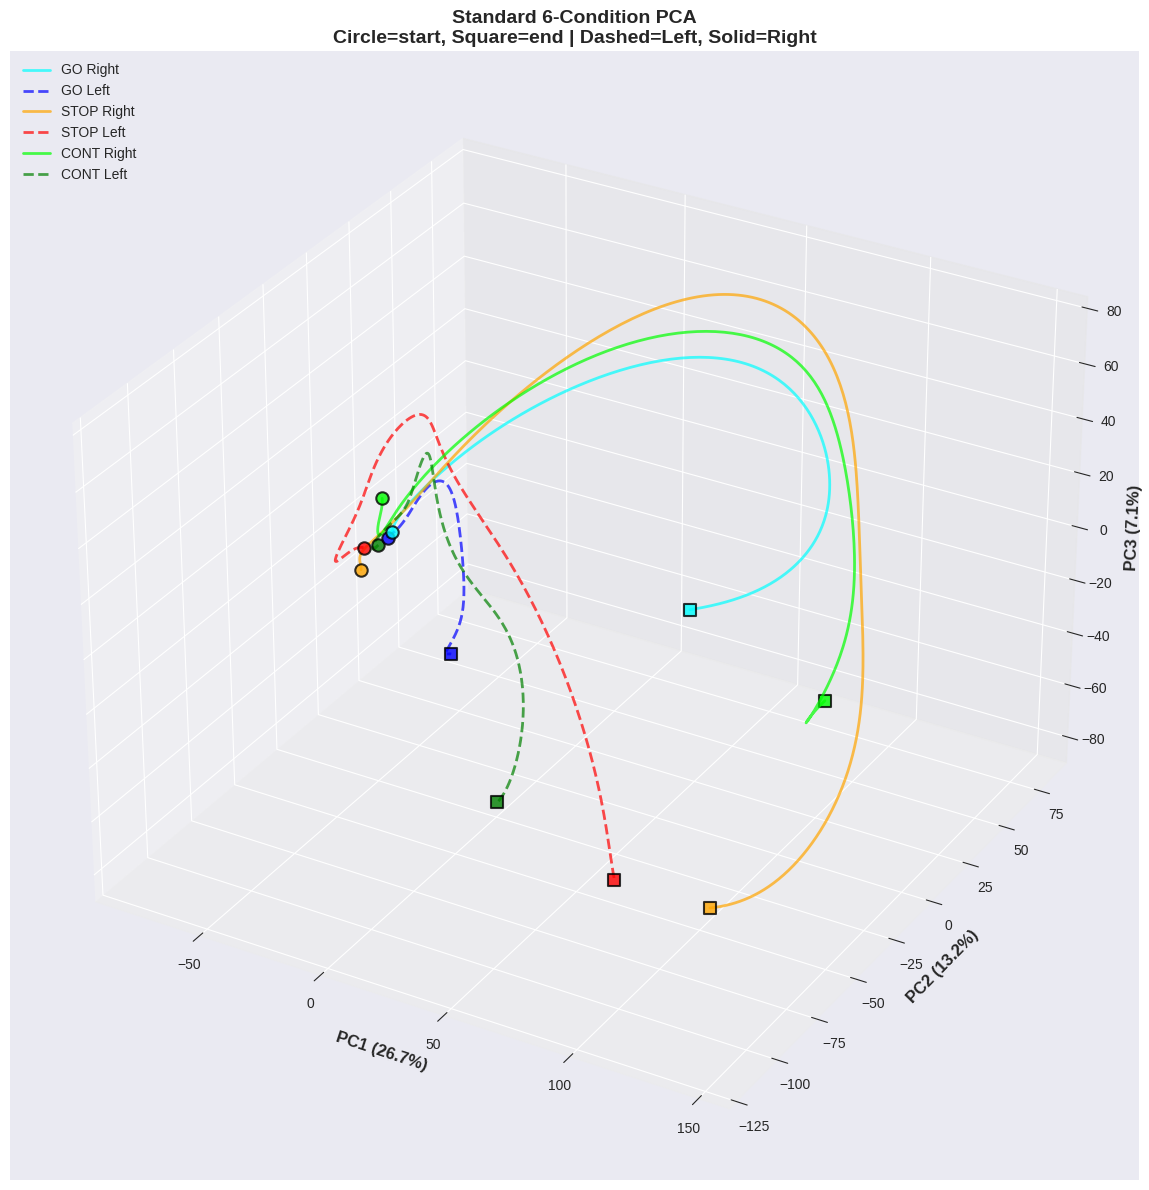

In [29]:
# Get all trajectories
all_traj = fpca3.get_fit_trajectories()

# 3D plot
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

plot_config = {
    'GO_R': ('cyan', 'GO Right', '-'),
    'GO_L': ('blue', 'GO Left', '--'),
    'STOP_R': ('orange', 'STOP Right', '-'),
    'STOP_L': ('red', 'STOP Left', '--'),
    'CONT_R': ('lime', 'CONT Right', '-'),
    'CONT_L': ('green', 'CONT Left', '--'),
}

for label, (color, name, linestyle) in plot_config.items():
    traj = all_traj[label]
    ax.plot(traj[0, :], traj[1, :], traj[2, :],
            label=name, color=color, linewidth=2, alpha=0.7, linestyle=linestyle)
    ax.scatter(traj[0, 0], traj[1, 0], traj[2, 0],
              marker='o', s=80, color=color, edgecolors='black', linewidths=1.5, alpha=0.8)
    ax.scatter(traj[0, -1], traj[1, -1], traj[2, -1],
              marker='s', s=80, color=color, edgecolors='black', linewidths=1.5, alpha=0.8)

var_ratios = fpca3.pca_model.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({var_ratios[0]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({var_ratios[1]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_zlabel(f'PC3 ({var_ratios[2]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_title('Standard 6-Condition PCA\nCircle=start, Square=end | Dashed=Left, Solid=Right',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()

## 5. Plotting Helper Functions

Create reusable functions for 2D projection matrices and PC time series plots.

In [30]:
def plot_pca_2d_projections(trajectories_dict, explained_variance_ratio, n_pcs=3,
                            figsize=(16, 16), title=None):
    """
    Plot a matrix of 2D projections showing all pairwise PC combinations.

    Parameters:
    -----------
    trajectories_dict : dict
        Dictionary mapping condition labels to trajectory arrays (n_components, n_time_bins)
    explained_variance_ratio : array
        Explained variance ratio for each PC
    n_pcs : int
        Number of PCs to visualize (default: 3)
    figsize : tuple
        Figure size (default: (16, 16))
    title : str, optional
        Overall figure title

    Returns:
    --------
    fig, axes : matplotlib figure and axes
    """
    fig, axes = plt.subplots(n_pcs, n_pcs, figsize=figsize)

    # Define trajectory plotting configuration
    plot_config = {
        'GO_R': ('cyan', 'GO Right', '-'),
        'GO_L': ('blue', 'GO Left', '--'),
        'STOP_R': ('orange', 'STOP Right', '-'),
        'STOP_L': ('red', 'STOP Left', '--'),
        'CONT_R': ('lime', 'CONT Right', '-'),
        'CONT_L': ('green', 'CONT Left', '--'),
        # Add more flexible labels for custom conditions
        'GO_R_early': ('cyan', 'GO Right (early)', '-'),
        'GO_L_early': ('blue', 'GO Left (early)', '--'),
        'GO_R_late': ('orange', 'GO Right (late)', '-'),
        'GO_L_late': ('red', 'GO Left (late)', '--'),
    }

    for i in range(n_pcs):
        for j in range(n_pcs):
            ax = axes[i, j]

            if i == j:
                # Diagonal: show PC index and variance
                ax.text(0.5, 0.5, f'PC{i+1}\n{explained_variance_ratio[i]*100:.1f}%',
                       ha='center', va='center', fontsize=14, fontweight='bold')
                ax.set_xlim(0, 1)
                ax.set_ylim(0, 1)
                ax.axis('off')
            else:
                # Off-diagonal: plot trajectories
                for label, traj in trajectories_dict.items():
                    # Get plot config or use defaults
                    if label in plot_config:
                        color, display_label, linestyle = plot_config[label]
                    else:
                        # Default styling for unknown labels
                        color = 'gray'
                        display_label = label
                        linestyle = '-'

                    ax.plot(traj[j, :], traj[i, :],
                           label=display_label, color=color, linewidth=1.2,
                           alpha=0.6, linestyle=linestyle)

                    # Mark start points
                    ax.scatter(traj[j, 0], traj[i, 0],
                              marker='o', s=30, color=color, edgecolors='black',
                              linewidths=0.5, zorder=5, alpha=0.7)

                ax.grid(alpha=0.3)

                # Labels only on edges
                if i == n_pcs - 1:
                    ax.set_xlabel(f'PC{j+1}', fontsize=10)
                if j == 0:
                    ax.set_ylabel(f'PC{i+1}', fontsize=10)

                # Legend only on top-right
                if i == 0 and j == n_pcs - 1:
                    ax.legend(fontsize=7, loc='upper right', framealpha=0.8)

    if title:
        fig.suptitle(title, fontsize=16, fontweight='bold', y=0.995)

    plt.tight_layout()
    return fig, axes


def plot_pca_timeseries(trajectories_dict, time_axes_dict, explained_variance_ratio,
                        n_pcs=3, figsize=(16, 12), title=None):
    """
    Plot PC time series showing how each PC varies over time for all conditions.

    Parameters:
    -----------
    trajectories_dict : dict
        Dictionary mapping condition labels to trajectory arrays (n_components, n_time_bins)
    time_axes_dict : dict
        Dictionary mapping condition labels to time axes (arrays)
    explained_variance_ratio : array
        Explained variance ratio for each PC
    n_pcs : int
        Number of PCs to visualize (default: 3)
    figsize : tuple
        Figure size (default: (16, 12))
    title : str, optional
        Overall figure title

    Returns:
    --------
    fig, axes : matplotlib figure and axes
    """
    fig, axes = plt.subplots(n_pcs, 1, figsize=figsize)

    # Ensure axes is always an array
    if n_pcs == 1:
        axes = [axes]

    # Define trajectory plotting configuration
    plot_config = {
        'GO_R': ('cyan', 'GO Right', '-'),
        'GO_L': ('blue', 'GO Left', '--'),
        'STOP_R': ('orange', 'STOP Right', '-'),
        'STOP_L': ('red', 'STOP Left', '--'),
        'CONT_R': ('lime', 'CONT Right', '-'),
        'CONT_L': ('green', 'CONT Left', '--'),
        # Add more flexible labels
        'GO_R_early': ('cyan', 'GO Right (early)', '-'),
        'GO_L_early': ('blue', 'GO Left (early)', '--'),
        'GO_R_late': ('orange', 'GO Right (late)', '-'),
        'GO_L_late': ('red', 'GO Left (late)', '--'),
    }

    for i in range(n_pcs):
        ax = axes[i]

        # Plot trajectories
        for label, traj in trajectories_dict.items():
            time_axis = time_axes_dict[label]

            # Get plot config or use defaults
            if label in plot_config:
                color, display_label, linestyle = plot_config[label]
            else:
                color = 'gray'
                display_label = label
                linestyle = '-'

            ax.plot(time_axis, traj[i, :], label=display_label,
                   color=color, linewidth=2, alpha=0.7, linestyle=linestyle)

        # Formatting
        ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
        ax.axvline(0, color='black', linestyle=':', alpha=0.5, linewidth=1.5)
        ax.set_ylabel(f'PC{i+1}\n({explained_variance_ratio[i]*100:.1f}%)',
                     fontsize=11, fontweight='bold')
        ax.legend(loc='upper right', fontsize=8, ncol=2, framealpha=0.9)
        ax.grid(alpha=0.3)

        if i == 0 and title:
            ax.set_title(title, fontsize=14, fontweight='bold')
        if i == n_pcs - 1:
            ax.set_xlabel('Time (ms)', fontsize=11)

    plt.tight_layout()
    return fig, axes


print("✓ Plotting helper functions defined")
print("  - plot_pca_2d_projections(): Matrix of 2D PC projections")
print("  - plot_pca_timeseries(): PC time series plots")

✓ Plotting helper functions defined
  - plot_pca_2d_projections(): Matrix of 2D PC projections
  - plot_pca_timeseries(): PC time series plots


## 6. 2D Projection Matrix

Visualize all pairwise PC projections using the standard 6-condition data.

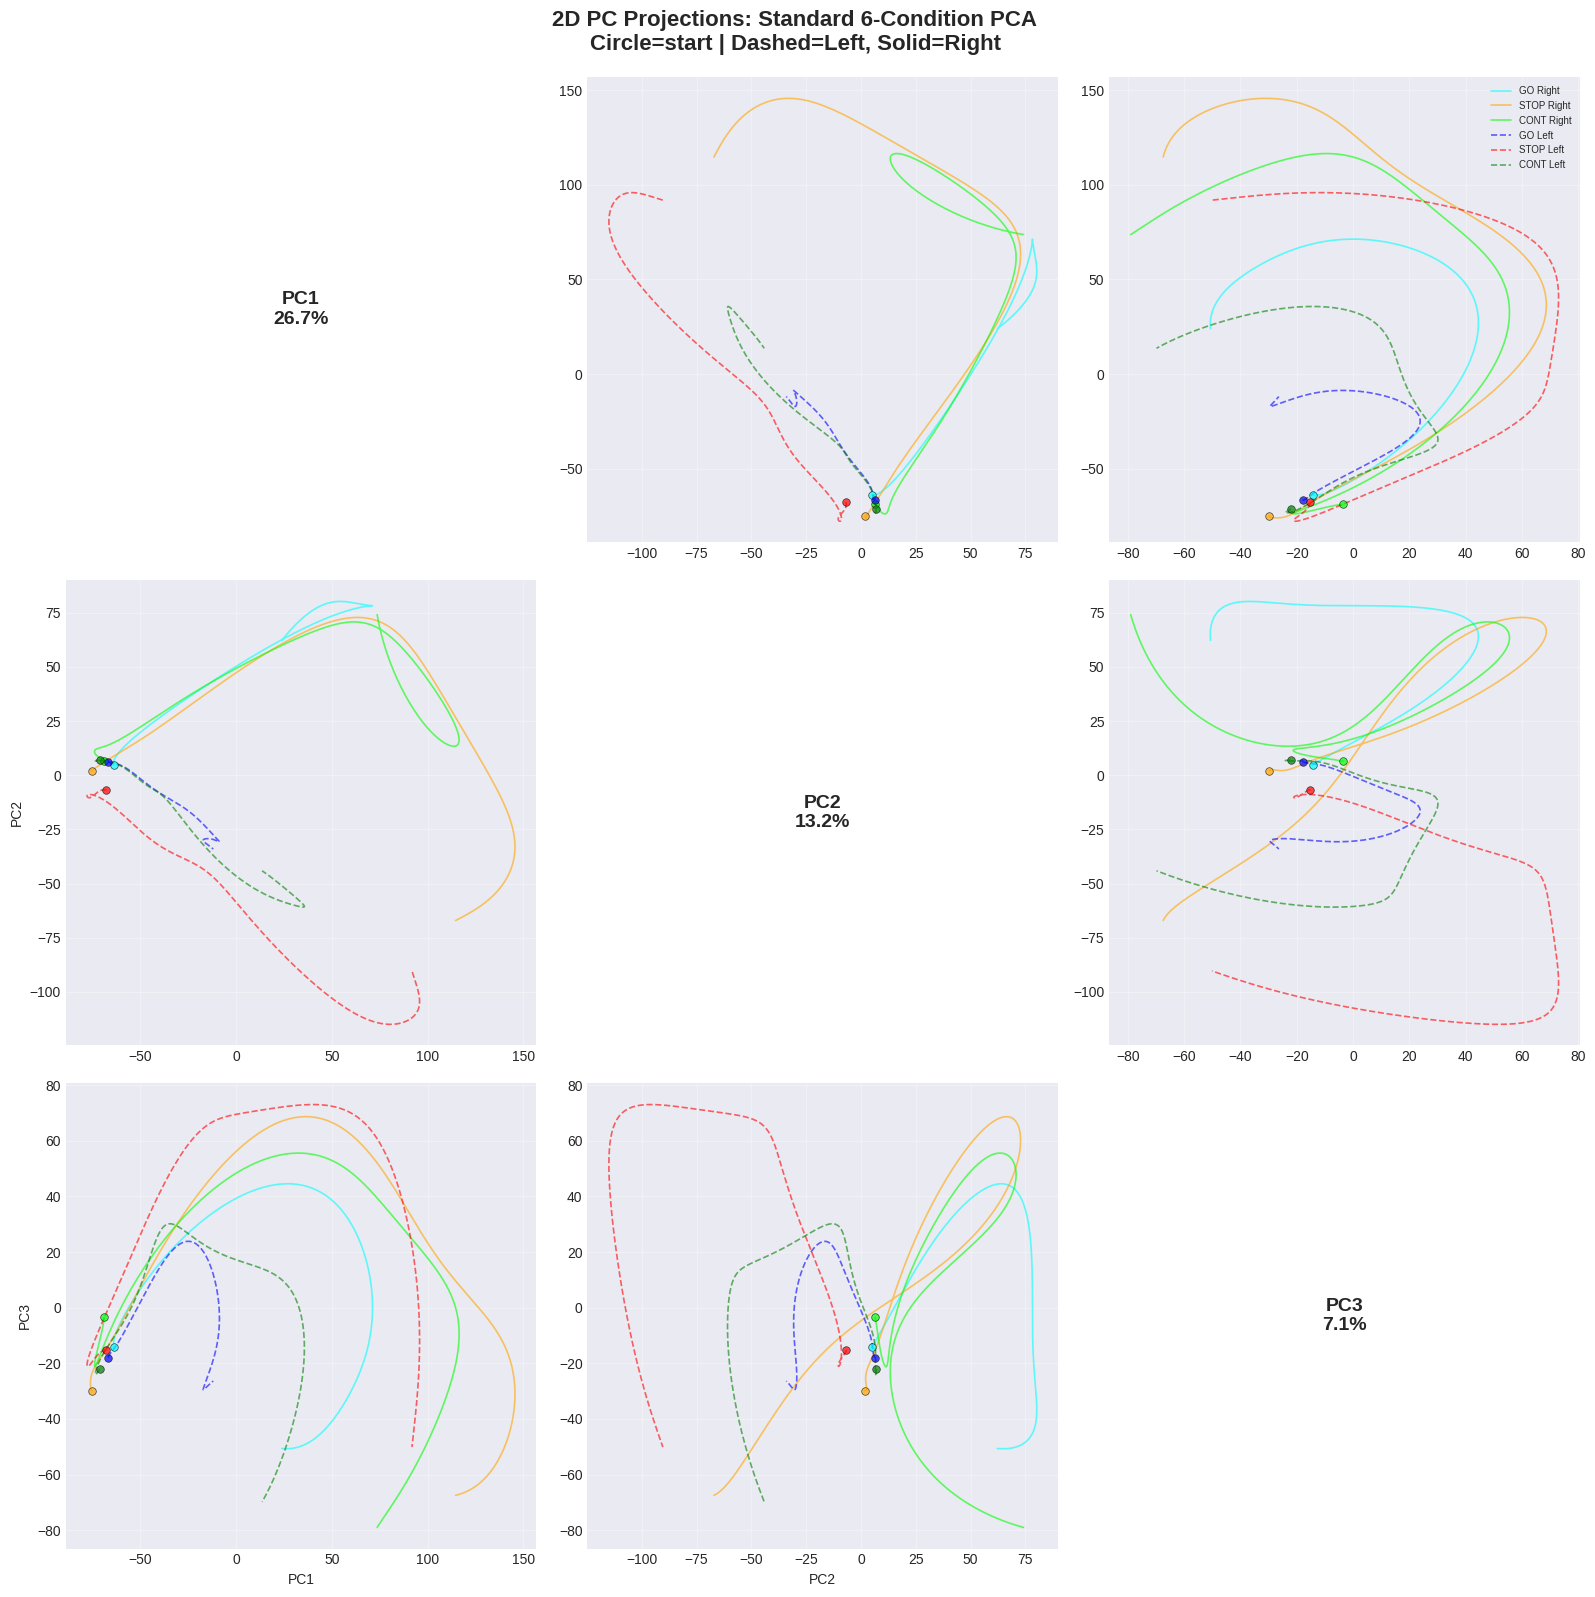

In [31]:
# Create 2D projection matrix for the standard 6-condition PCA
plot_pca_2d_projections(
    trajectories_dict=all_traj,
    explained_variance_ratio=fpca3.pca_model.explained_variance_ratio_,
    n_pcs=3,
    title='2D PC Projections: Standard 6-Condition PCA\nCircle=start | Dashed=Left, Solid=Right'
)
plt.show()

## 7. PC Time Series

Show how each PC varies over time for all conditions.

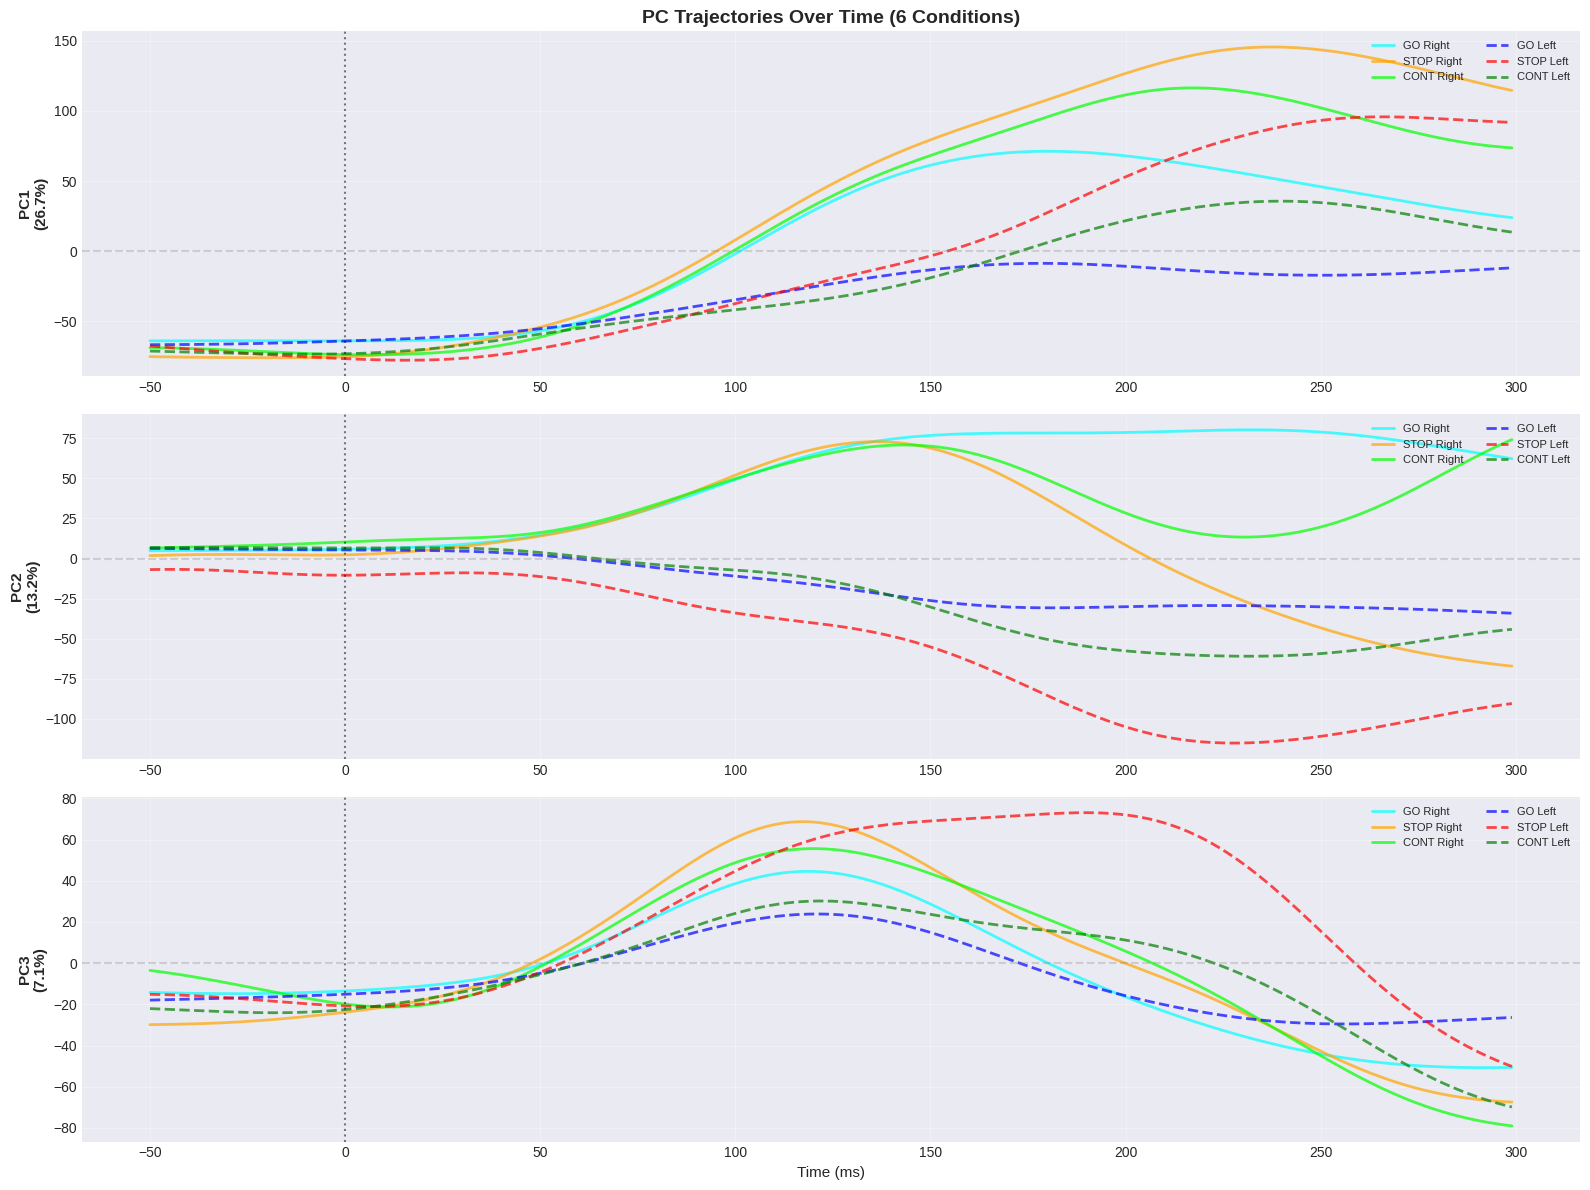

In [32]:
# Create time axes for each condition using FlexiblePCA's helper
time_axes = {}
for spec in standard_specs:
    time_axes[spec.label] = fpca3.get_time_axis(spec)

# Plot PC time series
plot_pca_timeseries(
    trajectories_dict=all_traj,
    time_axes_dict=time_axes,
    explained_variance_ratio=fpca3.pca_model.explained_variance_ratio_,
    n_pcs=3,
    title='PC Trajectories Over Time (6 Conditions)'
)
plt.show()

## 8. Example: 2D Projections and Time Series for Custom Conditions

Demonstrate the flexibility with the GO+STOP fit + CONT projection example.

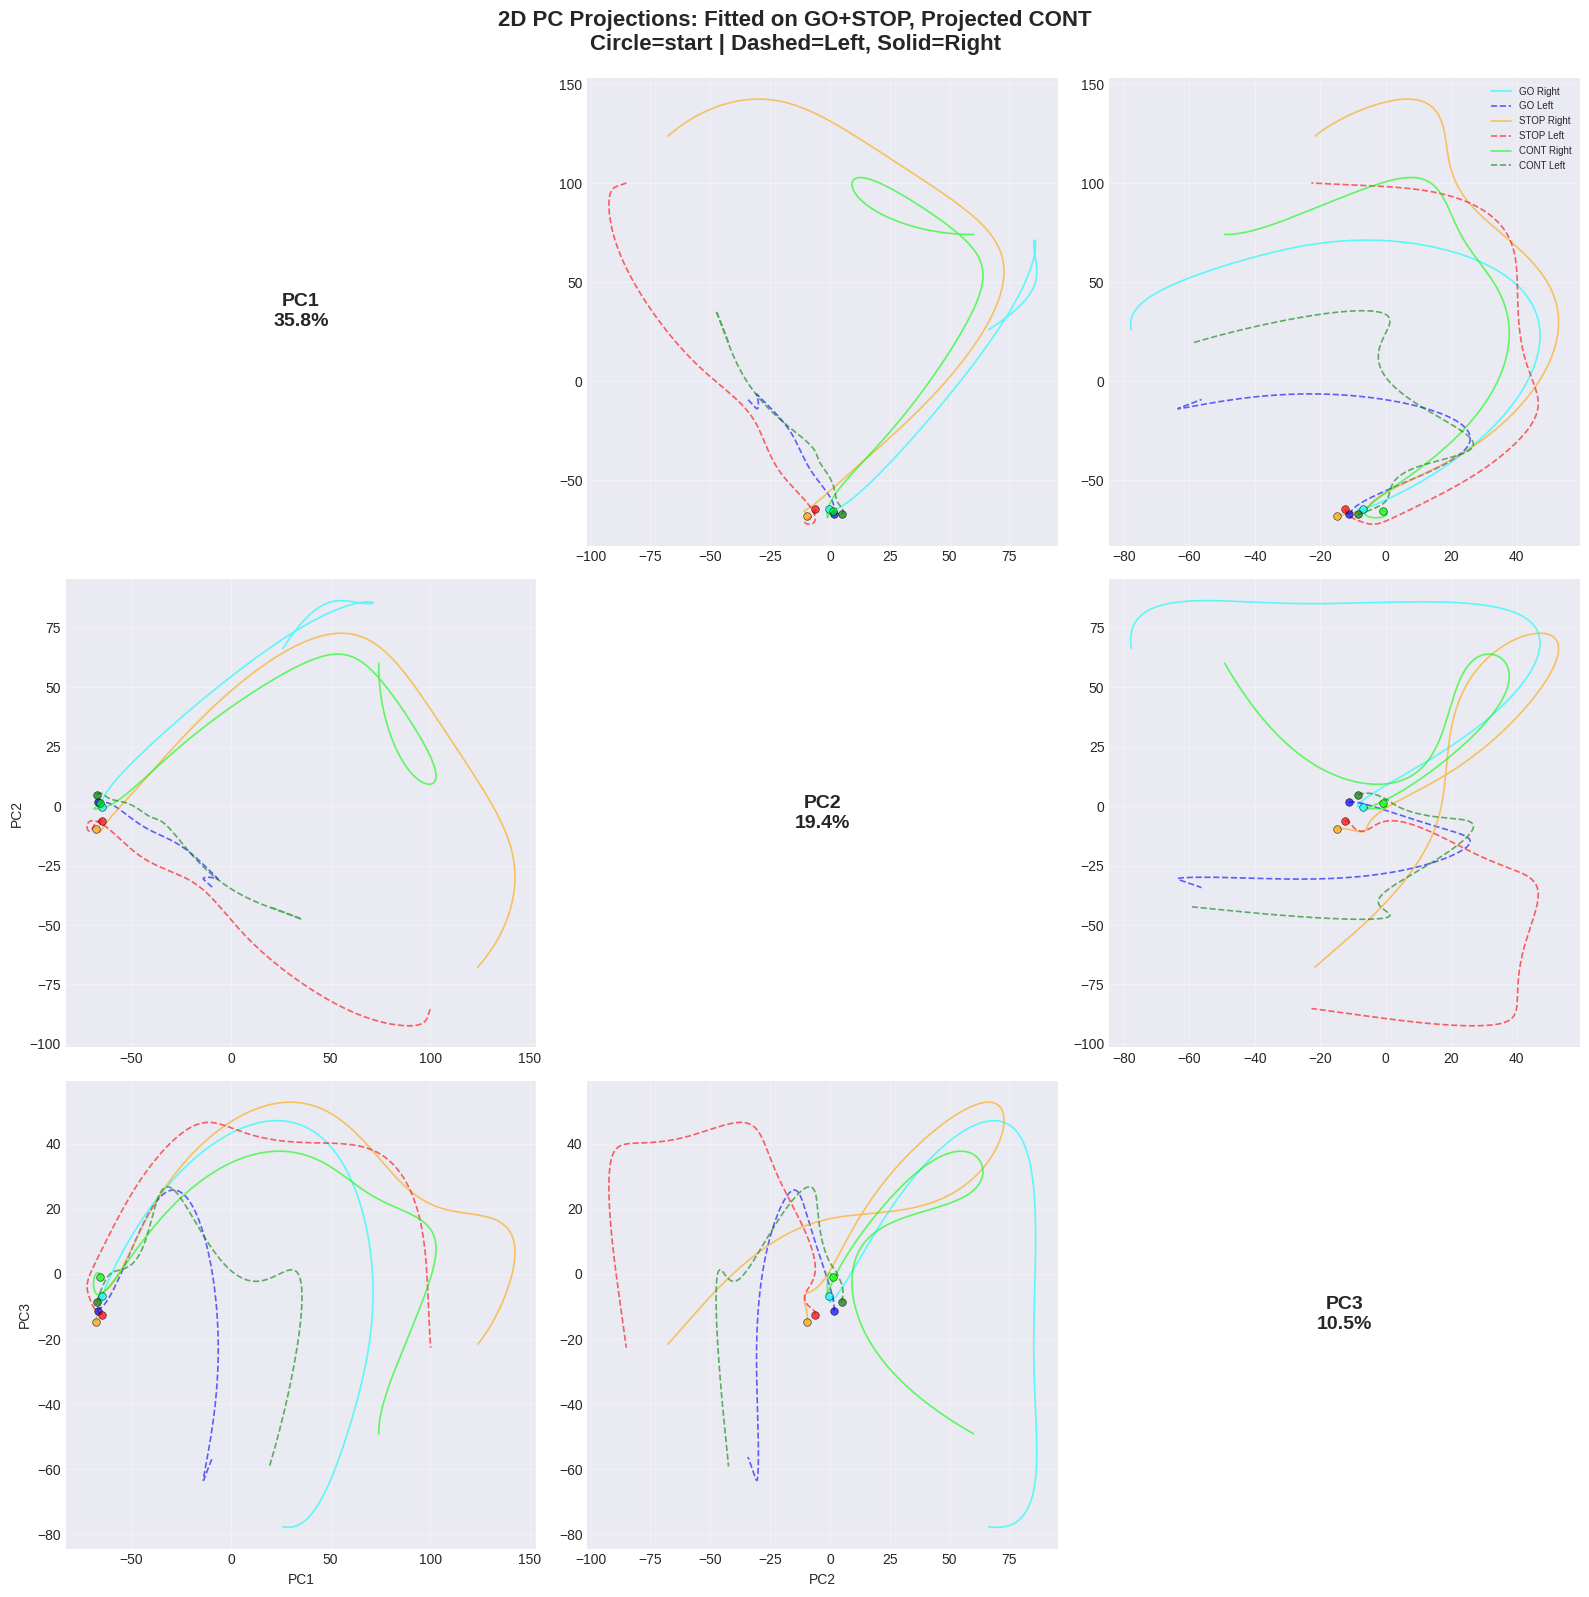

In [33]:
# Combine fit and projection trajectories from Example 1
all_trajectories_ex1 = {}
all_trajectories_ex1.update(fit_trajectories)
all_trajectories_ex1.update(projections)

# 2D projection matrix
plot_pca_2d_projections(
    trajectories_dict=all_trajectories_ex1,
    explained_variance_ratio=fpca.pca_model.explained_variance_ratio_,
    n_pcs=3,
    title='2D PC Projections: Fitted on GO+STOP, Projected CONT\nCircle=start | Dashed=Left, Solid=Right'
)
plt.show()

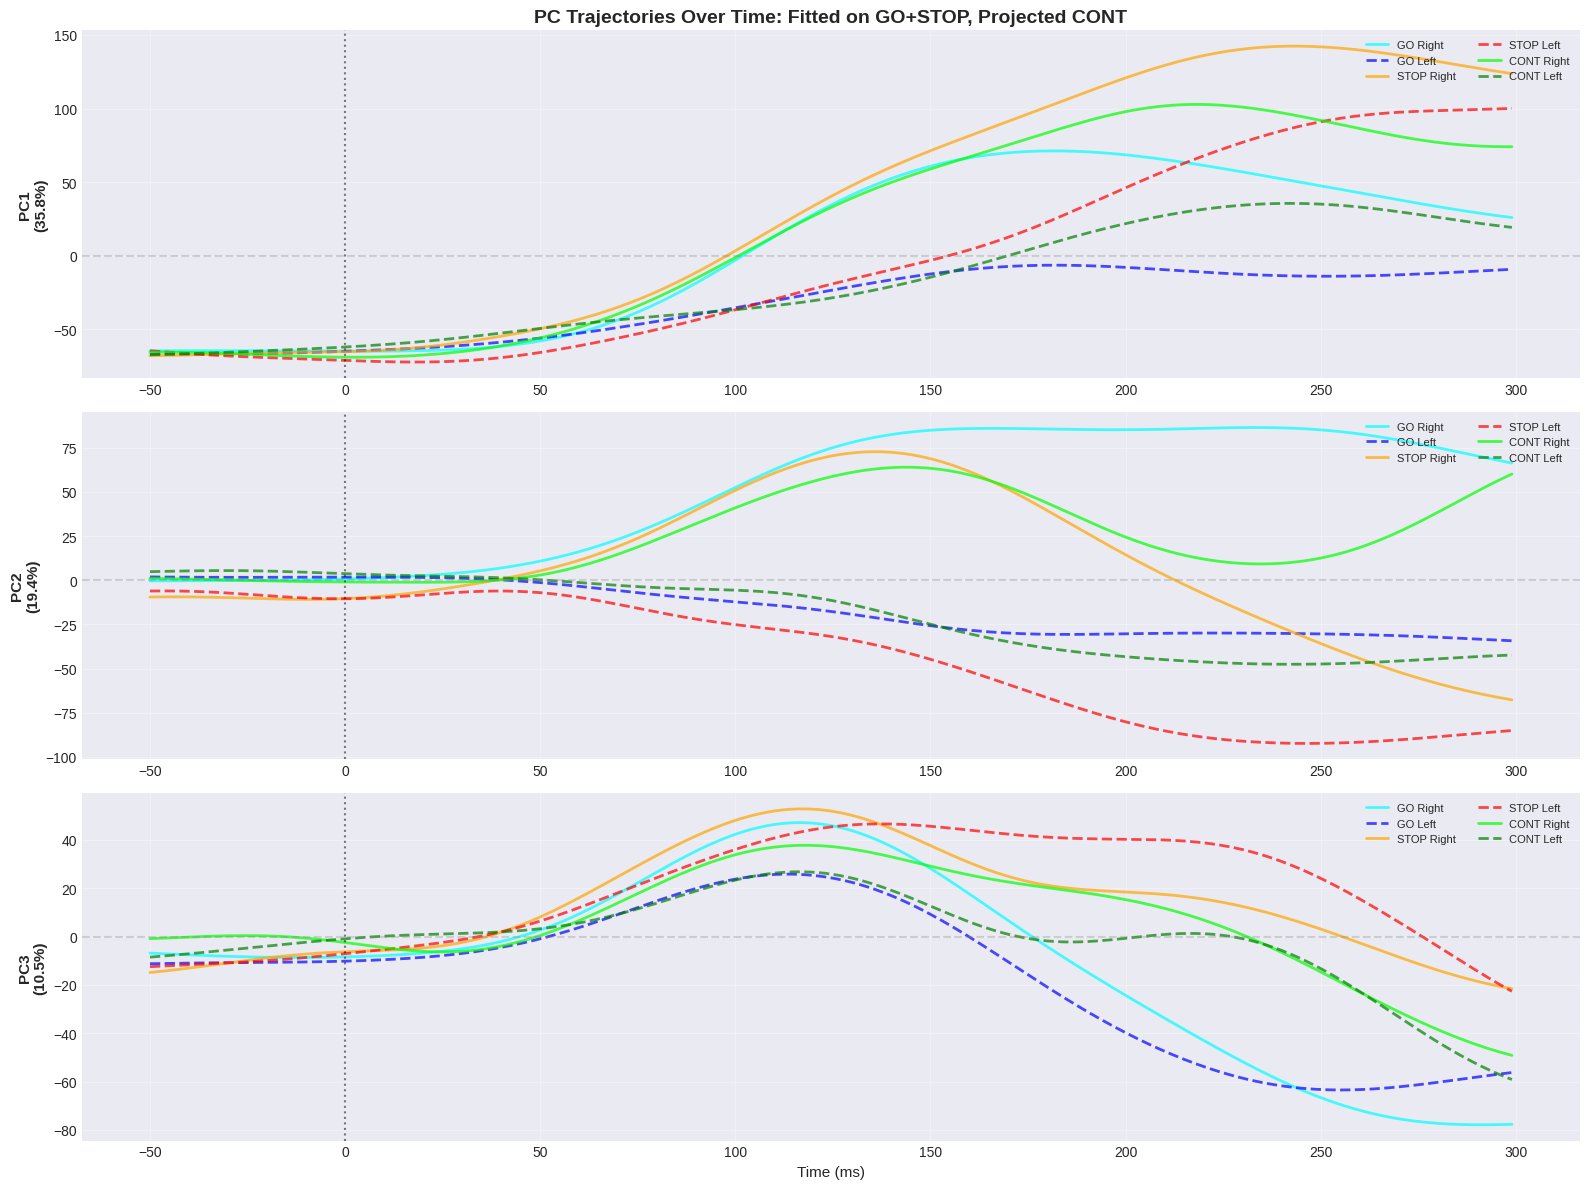

In [34]:
# Create time axes for all conditions
time_axes_ex1 = {}
for spec in fit_specs + proj_specs:
    time_axes_ex1[spec.label] = fpca.get_time_axis(spec)

# Plot PC time series
plot_pca_timeseries(
    trajectories_dict=all_trajectories_ex1,
    time_axes_dict=time_axes_ex1,
    explained_variance_ratio=fpca.pca_model.explained_variance_ratio_,
    n_pcs=3,
    title='PC Trajectories Over Time: Fitted on GO+STOP, Projected CONT'
)
plt.show()

## 9. Summary

The **FlexiblePCA** class provides:

1. **Flexible fitting**: Define arbitrary trial conditions for PCA fitting
2. **Flexible projection**: Project different conditions onto fitted PCs
3. **Easy specification**: `TrialSpec` objects make it clear what you're analyzing
4. **Helper functions**: `create_standard_specs()` for common use cases
5. **Time axis management**: `get_time_axis()` for plotting
6. **Comprehensive visualization**: 3D trajectories, 2D projection matrices, and PC time series

### Key advantages over fixed approaches:

- Can fit on any subset of conditions
- Can project any conditions (even different epochs/alignments)
- Reuse fitted PCA for multiple projections
- Compare how different conditions use the same neural space
- Investigate temporal evolution in fixed PC space
- Unified plotting functions eliminate code duplication